# Exploratory Data Analysis

This notebook loads the Grunnai signal data, cleans invalid values, creates basic summaries and figures, extracts operating periods, and compares each signal with DE vibration during operation.

## Setup

In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

from helper_functions import (
    clean_signals,
    correlate_with_vibration,
    extract_operating_periods,
    get_signal_df,
    load_signal_data,
)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)

DATA_FOLDER = Path("step_interpolation_10s/G2_relevant")
FIGURES_DIR = Path("figures")
REPORT_PATH = Path("signal_data_report.html")
EXCLUDED_SIGNALS_PATTERN = "vann|trykk oppstrom|trykk oppstrøm|set point"

FIGURES_DIR.mkdir(exist_ok=True)

## Load Data

In [2]:
dfs = load_signal_data(DATA_FOLDER)

# Show the available signals and units.
dfs[["name", "unit", "external_id"]]

,name,unit,external_id
0,Turbine inlet pressure,kPa,Hydrocord.StandardData.G2_Sjakt_Trykk(=A2=HB1=...
1,DE bearing temperature,°C,Scada.GRUN.AGG2.G2.LAGER.M_LAGTMP6
2,DE bearing oil temperature,°C,Scada.GRUN.AGG2.G2.LAGER.M_OLTMP2
3,DE vibration,mm/s RMS,Scada.GRUN.AGG2.G2.LAGER.M_VIBR1
4,Exciter current,A,Scada.GRUN.AGG2.G2.MAGN.M_I
5,Set point,MW,Scada.GRUN.AGG2.G2.MV.M_PSP
6,Generator active power,MW,Scada.GRUN.AGG2.G2.MV.M_P_MW
7,Total needle opening,%,Scada.GRUN.AGG2.TURB2.PADRAG.M_WCKT_POS
8,Rotational speed,%,Scada.GRUN.AGG2.TURB2.REG.M_TURT
9,VANN Trykk oppstrøm,pressure:bar,Scada.GRUN.AGG2.VANN.SJAKT.M_TRYKK


## Inspect and Clean Signals

In [3]:
# Get resampled / step-interpolated DE vibration signal
de_vib = get_signal_df(dfs, "DE vibration").copy()

# Inspect the largest values
de_vib.nlargest(20, "signal")[["Datetime", "signal"]]

,Datetime,signal
125757,2024-06-15 13:19:30,22.634289
1248649,2024-10-23 12:28:10,15.620693
1236560,2024-10-22 02:53:20,7.803798
150593,2024-06-18 10:18:50,1.743030
996890,2024-09-24 09:08:20,1.681909
121934,2024-06-15 02:42:20,1.555302
143957,2024-06-17 15:52:50,1.353386
4542,2024-06-01 12:37:00,1.332649
4543,2024-06-01 12:37:10,1.282442
23728,2024-06-03 17:54:40,1.245333


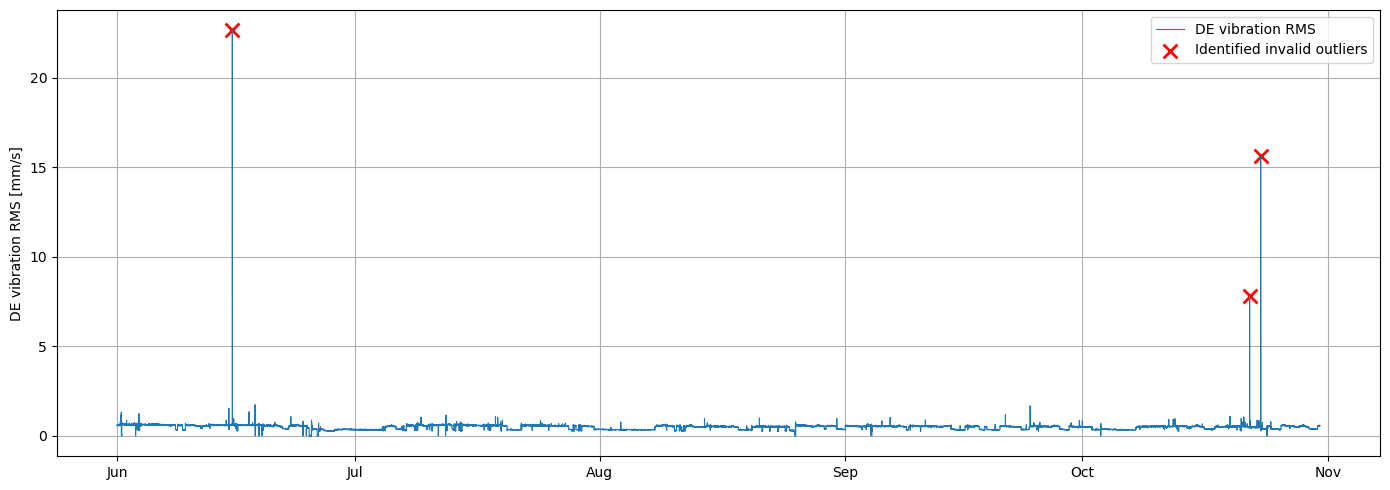

,Datetime,signal
125757,2024-06-15 13:19:30,22.634289
1248649,2024-10-23 12:28:10,15.620693
1236560,2024-10-22 02:53:20,7.803798


In [ ]:
# Select the three largest values as invalid outliers
outliers = de_vib.nlargest(3, "signal")

plt.figure(figsize=(14, 5))

plt.plot(
    de_vib["Datetime"],
    de_vib["signal"],
    linewidth=0.8,
    label="DE vibration RMS"
)

plt.scatter(
    outliers["Datetime"],
    outliers["signal"],
    s=100,
    marker="x",
    color="red",
    linewidths=2,
    label="Identified outliers"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.ylabel("DE vibration RMS [mm/s]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/resampled_de_vibration_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

outliers[["Datetime", "signal"]]

In [4]:
dfs, cleaning_table = clean_signals(dfs, vibration_max_value=5)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Turbine inlet pressure,759,0.0578
1,DE bearing temperature,4,0.0003
2,DE bearing oil temperature,10,0.0008
3,DE vibration,3,0.0002


## Profiling Report

In [ ]:
profile_df = pd.DataFrame()

for _, row in dfs.iterrows():
    profile_df[row["name"]] = row["signal_df"]["signal"].reset_index(drop=True)

profile = ProfileReport(
    profile_df,
    title="Signal data report",
    explorative=True,
)

profile.to_file(REPORT_PATH)

## Summary Statistics

In [5]:
summary_rows = []

for _, row in dfs.iterrows():
    name = row["name"]
    unit = row["unit"]
    signal_df = row["signal_df"]
    values = signal_df["signal"]
    unit_clean = str(unit).split(":")[-1].strip() if pd.notna(unit) else ""

    summary_rows.append({
        "Signal": name,
        "Unit": unit_clean,
        "Mean": values.mean(),
        "Std. dev.": values.std(),
        "Min": values.min(),
        "Max": values.max(),
        "Zero [%]": 100 * (values == 0).mean(),
        "Negative [%]": 100 * (values < 0).mean(),
        "99th percentile": values.quantile(0.99),
    })

summary_table = pd.DataFrame(summary_rows).round({
    "Mean": 3,
    "Std. dev.": 3,
    "Min": 3,
    "Max": 3,
    "Zero [%]": 2,
    "Negative [%]": 2,
    "99th percentile": 3,
})

summary_table

,Signal,Unit,Mean,Std. dev.,Min,Max,Zero [%],Negative [%],99th percentile
0,Turbine inlet pressure,kPa,3843.594,39.241,3737.572,3911.675,0.00,0.0,3893.645
1,DE bearing temperature,°C,43.430,3.047,30.281,58.229,0.00,0.0,54.394
2,DE bearing oil temperature,°C,43.957,3.028,29.175,60.227,0.00,0.0,50.020
3,DE vibration,mm/s RMS,0.494,0.107,0.000,1.743,0.04,0.0,0.648
4,Exciter current,A,6.015,1.150,0.000,18.103,0.57,0.0,7.773
5,Set point,megaw,6.133,3.076,0.000,10.320,0.00,0.0,10.320
6,Generator active power,MW,6.057,3.091,0.000,10.600,0.63,0.0,10.260
7,Total needle opening,percent,66.098,15.239,0.000,93.817,0.00,0.0,90.598
8,Rotational speed,%,99.489,7.009,0.000,118.273,0.42,0.0,100.215
9,VANN Trykk oppstrøm,bar,37.346,0.468,0.000,38.063,0.01,0.0,37.844


## Signal Plots

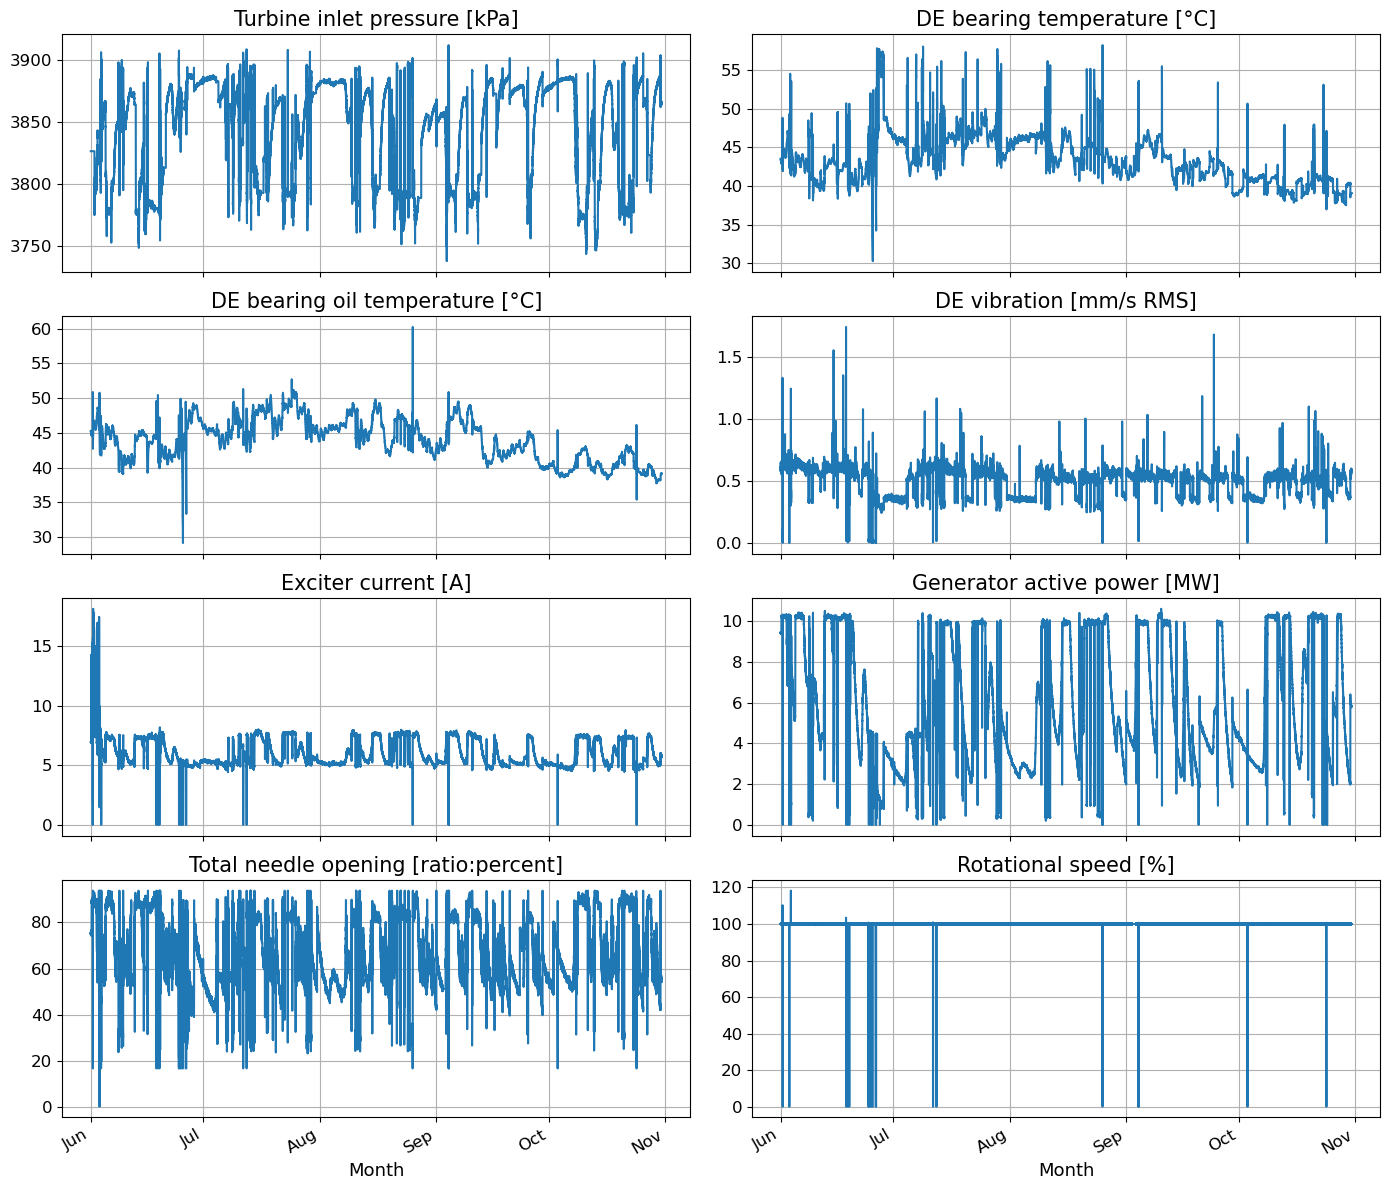

In [6]:
plot_dfs = dfs.loc[
    ~dfs["name"].str.lower().str.contains(EXCLUDED_SIGNALS_PATTERN, na=False)
].reset_index(drop=True)

num_plots = len(plot_dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 3.0 * num_rows),
)

axes = axes.flatten()

for i, row in plot_dfs.iterrows():
    name = row["name"]
    signal_df = row["signal_df"]
    unit = row["unit"]
    title = f"{name} [{unit}]" if pd.notna(unit) else name

    axes[i].plot(signal_df["Datetime"], signal_df["signal"])
    axes[i].set_title(title, fontsize=15)
    axes[i].set_xlabel("Month", fontsize=13)
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="both", labelsize=12)
    axes[i].grid(True)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

for ax in axes[num_plots:]:
    ax.remove()

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "selected_signal_values.png", dpi=300, bbox_inches="tight")
plt.show()

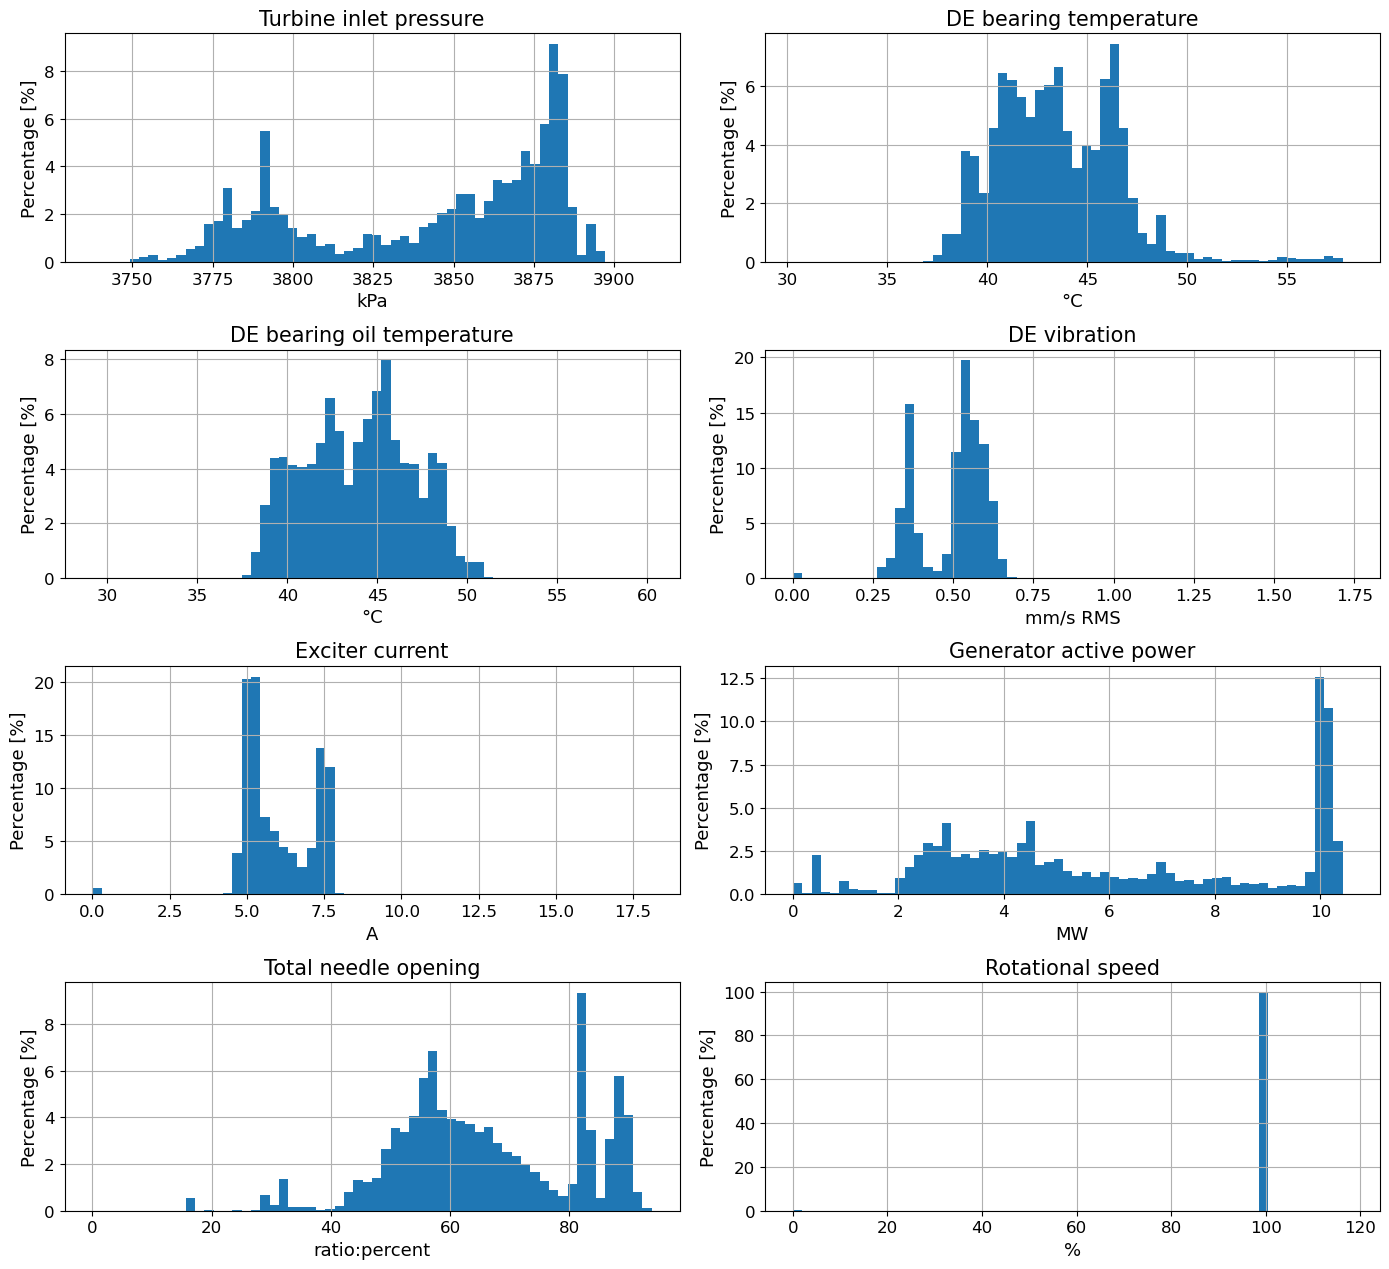

In [7]:
num_plots = len(plot_dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 3.2 * num_rows),
)

axes = axes.flatten()

for i, row in plot_dfs.iterrows():
    name = row["name"]
    signal_df = row["signal_df"]
    unit = row["unit"]
    values = signal_df["signal"].dropna()
    weights = np.ones(len(values)) * 100 / len(values)

    axes[i].hist(values, bins=60, weights=weights)
    axes[i].set_title(name, fontsize=15)
    axes[i].set_xlabel(unit if pd.notna(unit) else "Signal value", fontsize=13)
    axes[i].set_ylabel("Percentage [%]", fontsize=13)
    axes[i].tick_params(axis="both", labelsize=12)
    axes[i].grid(True)

for ax in axes[num_plots:]:
    ax.remove()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "selected_signal_histograms_percentage.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Operating Periods

In [8]:
speed = get_signal_df(dfs, "Rotational speed")
power = get_signal_df(dfs, "Generator active power")

operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30,
)

operating_periods.head()

,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


## Correlation With Vibration

In [9]:
corr_df = correlate_with_vibration(dfs, operating_periods, vib_name)

corr_df

,Signal,Pearson,Distance
0,Generator active power,0.726454,0.719434
1,Set point,0.723595,0.717474
2,VANN Trykk oppstrøm,-0.603612,0.631563
3,Exciter current,0.630788,0.628380
4,Turbine inlet pressure,-0.608323,0.623502
5,Total needle opening,0.485191,0.435836
6,DE bearing oil temperature,0.231498,0.236057
7,DE bearing temperature,-0.209588,0.219484
8,Rotational speed,0.024095,0.031077


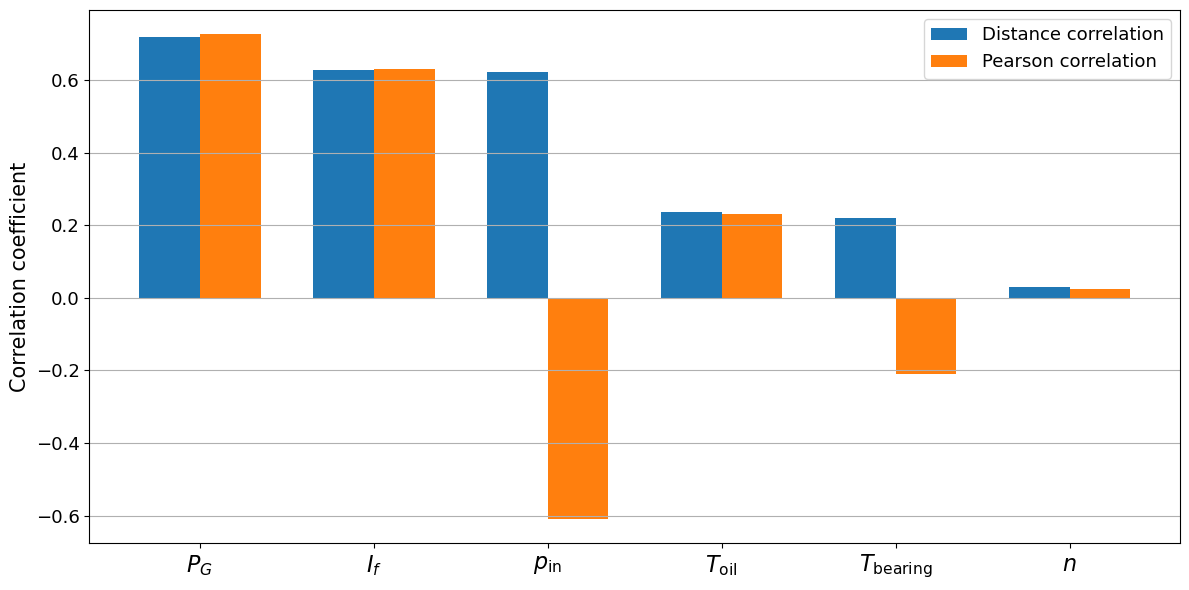

In [10]:
symbol_map = {
    "Turbine inlet pressure": r"$p_{\mathrm{in}}$",
    "DE bearing temperature": r"$T_{\mathrm{bearing}}$",
    "DE bearing oil temperature": r"$T_{\mathrm{oil}}$",
    "DE vibration": r"$V_{\mathrm{DE}}$",
    "Exciter current": r"$I_f$",
    "Generator active power": r"$P_G$",
    "Total needle opening position": r"$O$",
    "Rotational speed": r"$n$",
}

corr_plot_df = corr_df.loc[
    ~corr_df["Signal"].str.lower().str.contains(EXCLUDED_SIGNALS_PATTERN, na=False)
].copy()

corr_plot_df["Symbol"] = corr_plot_df["Signal"].map(symbol_map)
corr_plot_df = corr_plot_df.dropna(subset=["Symbol"]).reset_index(drop=True)

x = np.arange(len(corr_plot_df))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    corr_plot_df["Distance"],
    width=width,
    label="Distance correlation",
)
plt.bar(
    x + width / 2,
    corr_plot_df["Pearson"],
    width=width,
    label="Pearson correlation",
)

plt.xticks(x, corr_plot_df["Symbol"], fontsize=16)
plt.yticks(fontsize=13)
plt.ylabel("Correlation coefficient", fontsize=15)
plt.grid(axis="y")
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "correlation_with_vibration_operating_periods.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()